#### paper implementation

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import math

# ==========================================
# 1. ARCFACE LOSS CLASSIFICATION LAYER
# ==========================================

class ArcFaceLayer(nn.Module):
    """
    Implements the Additive Angular Margin Loss (ArcFace)[cite: 143, 196].
    This forces the model to learn highly discriminative representation vectors.
    """
    def __init__(self, in_features, out_classes, s=30.0, m=0.7):
        super(ArcFaceLayer, self).__init__()
        self.in_features = in_features
        self.out_classes = out_classes
        self.s = s # Scale parameter
        self.m = m # Margin parameter

        # Learnable weight matrix
        self.weight = nn.Parameter(torch.FloatTensor(out_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, features, labels=None):
        # Normalize features and weights
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))

        # If no labels are provided (Inference phase), just return the scaled logits
        if labels is None:
            return cosine * self.s

        # Training phase: Apply angular margin to the target class
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        # Create one-hot encoded mask
        one_hot = torch.zeros(cosine.size(), device=features.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        # Apply margin only to the target class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s

        return output

# ==========================================
# 2. SW-WAVENET ARCHITECTURE BLOCKS
# ==========================================
class WavegramNet(nn.Module):
    """Extracts the Wavegram from the raw 1-D waveform[cite: 34, 78, 81]."""
    def __init__(self):
        super(WavegramNet, self).__init__()
        # Input: 1 channel, Output: 128 channels, Kernel: 1024, Stride: 512.
        # Padding ensures the output sequence length is exactly 313 to match the spectrogram.
        self.conv = nn.Conv1d(1, 128, kernel_size=1024, stride=512, padding=512)

    def forward(self, x):
        return self.conv(x)


class DilatedResidualBlock(nn.Module):
    """The internal structure of the dilated residual block[cite: 112, 118]."""
    def __init__(self, channels, dilation):
        super(DilatedResidualBlock, self).__init__()
        # 2x1 dilated causal convolution[cite: 118].
        self.dilated_conv = nn.Conv1d(channels, channels, kernel_size=2, dilation=dilation)
        self.batch_norm = nn.BatchNorm1d(channels) # [cite: 118]

        # 1x1 convolutions for output and skip connections [cite: 118]
        self.conv_1x1_res = nn.Conv1d(channels, channels, kernel_size=1)
        self.conv_1x1_skip = nn.Conv1d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        # Apply padding dynamically for causality
        pad_size = self.dilated_conv.dilation[0] * (self.dilated_conv.kernel_size[0] - 1)
        padded_x = F.pad(x, (pad_size, 0))
        out = self.dilated_conv(padded_x)

        out = self.batch_norm(out)

        # Gated activation: splits channels internally or applies to same channels.
        # Paper implies applying Tanh and Sigmoid[cite: 118]. We apply element-wise gating.
        out = torch.tanh(out) * torch.sigmoid(out)

        res_out = self.conv_1x1_res(out) + residual
        skip_out = self.conv_1x1_skip(out)

        return res_out, skip_out


class ModifiedWaveNet(nn.Module):
    """WaveNet encoder with Representation Compression[cite: 116, 117]."""
    def __init__(self, in_channels=128, out_channels=512, time_frames=313):
        super(ModifiedWaveNet, self).__init__()

        # Initial Causal Conv 1D
        self.causal_conv = nn.Conv1d(in_channels, out_channels, kernel_size=2)

        # 3 Residual Stacks, each with dilations [1, 2, 4, 8] [cite: 105, 132]
        self.blocks = nn.ModuleList()
        for _ in range(3):
            for dilation in [1, 2, 4, 8]:
                self.blocks.append(DilatedResidualBlock(channels=out_channels, dilation=dilation))

        # Representation Compression Module [cite: 119]
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        # Depthwise Conv1D squashes the time dimension (313 -> 1) [cite: 105, 119]
        self.depthwise_conv = nn.Conv1d(out_channels, out_channels, kernel_size=time_frames, groups=out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.final_conv = nn.Conv1d(out_channels, 128, kernel_size=1) #

    def forward(self, x):
        padded_x = F.pad(x, (1, 0))
        x = self.causal_conv(padded_x)

        skip_connections = []
        for block in self.blocks:
            x, skip = block(x)
            skip_connections.append(skip)

        out = sum(skip_connections)

        # Compression [cite: 119, 120]
        out = self.bn1(out)
        out = self.relu(out)
        out = self.depthwise_conv(out)
        out = self.bn2(out)
        out = self.final_conv(out)

        return out.squeeze(2) # Output shape: (Batch, 128)


# ==========================================
# 3. COMPLETE SW-WAVENET PIPELINE
# ==========================================
class SW_WaveNet_Pipeline(nn.Module):
    """End-to-end model encompassing log-mel extraction, WaveNets, and ArcFace."""
    def __init__(self, sample_rate=16000, num_classes=41):
        super(SW_WaveNet_Pipeline, self).__init__()

        self.num_classes = num_classes

        # Log-Mel Spectrogram Extractor (Transforms raw audio inside the model)
        # Hop length: 512, Window size: 1024, Mel filters: 128 [cite: 131]
        self.mel_extractor = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

        # Parallel WaveNets [cite: 59, 82]
        self.wavegram_net = WavegramNet()
        self.wavenet_spectrogram = ModifiedWaveNet(in_channels=128, out_channels=512, time_frames=313)
        self.wavenet_wavegram = ModifiedWaveNet(in_channels=128, out_channels=512, time_frames=313)

        # ArcFace Classification [cite: 121, 143]
        # Input features: 128 (Spectrogram) + 128 (Wavegram) = 256
        self.arcface = ArcFaceLayer(in_features=256, out_classes=num_classes, s=30.0, m=0.7)

    def forward(self, raw_audio, labels=None):
        """
        raw_audio: Tensor of shape (Batch, 1, 160000) for 10s audio [cite: 128]
        labels: Tensor of shape (Batch,) containing true Machine IDs (Required for training)
        """
        # 1. Extract Log-Mel Spectrogram dynamically [cite: 63, 65, 66]
        # Shape goes from (Batch, 1, 160000) -> (Batch, 128, 313)
        mel_spec = self.mel_extractor(raw_audio).squeeze(1)
        log_mel_spec = self.amplitude_to_db(mel_spec)

        # 2. Extract Wavegram [cite: 78, 81]
        wavegram = self.wavegram_net(raw_audio)

        # 3. Get Representation Vectors [cite: 51, 60]
        vec_spec = self.wavenet_spectrogram(log_mel_spec)
        vec_wave = self.wavenet_wavegram(wavegram)

        # 4. Combine vectors [cite: 51, 60]
        combined_vec = torch.cat((vec_spec, vec_wave), dim=1) # Shape: (Batch, 256)

        # 5. Classification Logits via ArcFace [cite: 60, 121]
        logits = self.arcface(combined_vec, labels)

        return logits

    def get_anomaly_score(self, raw_audio, target_machine_id):
        """
        Inference method to calculate the anomaly score.
        The score is the negative log probability of the expected machine ID.
        """
        self.eval() # Ensure model is in evaluation mode
        with torch.no_grad():
            # Get logits without applying the angular margin (labels=None)
            logits = self.forward(raw_audio, labels=None)

            # Convert logits to probabilities using Softmax [cite: 121]
            probs = F.softmax(logits, dim=1)

            # Extract the probability of the target Machine ID
            target_prob = probs[0, target_machine_id].item()

            # Calculate anomaly score (Negative Log Probability)
            # Add a tiny epsilon to prevent log(0)
            anomaly_score = -math.log(target_prob + 1e-9)

        return anomaly_score


In [23]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader

class MachineAudioDataset(Dataset):
    """Loads raw audio and extracts the machine ID from the filename."""
    def __init__(self, folder_path, expected_samples=160000):
        self.file_paths = []
        self.labels = []
        self.expected_samples = expected_samples

        # Gather all .wav files
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.wav'):
                self.file_paths.append(os.path.join(folder_path, file_name))

                # --- LABEL EXTRACTION ---
                # We assume your filenames look something like: "normal_id_02_clip.wav"
                # You MUST adapt this logic to parse the integer ID from your specific filenames!
                try:
                    # Example: splitting by '_' and grabbing the item after 'id'
                    parts = file_name.split('_')
                    id_index = parts.index('id') + 1
                    machine_id = int(parts[id_index])
                    self.labels.append(machine_id)
                except (ValueError, IndexError):
                    # Fallback if no ID is found (only works if you are forcing pseudo-classes later)
                    self.labels.append(0)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]

        # Load raw audio (torchaudio output is usually [Channels, Time])
        signal, sr = torchaudio.load(path)

        # Pad or truncate to ensure exactly 10 seconds (160,000 samples)
        if signal.shape[1] < self.expected_samples:
            pad_width = self.expected_samples - signal.shape[1]
            signal = torch.nn.functional.pad(signal, (0, pad_width))
        elif signal.shape[1] > self.expected_samples:
            signal = signal[:, :self.expected_samples]

        return signal, torch.tensor(label, dtype=torch.long)

In [24]:
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import numpy as np

# Define Paths
TRAIN_DIR = "/content/Dataset/water pump audio for anomaly detection/train-normal/"
TEST_NORMAL_DIR = "/content/Dataset/water pump audio for anomaly detection/test-normal/"
ANOMALY_DIR = "/content/Dataset/water pump audio for anomaly detection/anomaly/"

# Hyperparameters from the paper
BATCH_SIZE = 64
EPOCHS = 120
LEARNING_RATE = 0.0001
NUM_CLASSES = 41 # Adjust this to the actual number of unique machine IDs in your dataset

# Setup DataLoaders
train_dataset = MachineAudioDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

test_normal_dataset = MachineAudioDataset(TEST_NORMAL_DIR)
anomaly_dataset = MachineAudioDataset(ANOMALY_DIR)


In [27]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model (Assuming SW_WaveNet_Pipeline is defined from the previous script)
model = SW_WaveNet_Pipeline(num_classes=NUM_CLASSES).to(device)

# Optimizer & Scheduler exactly as defined in paper
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

# ==========================================
# TRAINING PHASE (Uses only train-normal)
# ==========================================
print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for audio, labels in train_loader:
        audio, labels = audio.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass (labels are required to calculate ArcFace angular margin)
        logits = model(audio, labels=labels)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step() # Apply cosine annealing decay

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {running_loss/len(train_loader):.4f}")

# ==========================================
# EVALUATION PHASE (Uses test-normal and anomaly)
# ==========================================
print("\nStarting Evaluation...")
model.eval()

# We evaluate our method using the area under the receiver operating characteristic (ROC) curve (AUC)[cite: 145].
y_true = []
y_scores = []

with torch.no_grad():

    # 1. Process Normal Test Clips (Label = 0 for AUC calculation)
    for audio, true_machine_id in DataLoader(test_normal_dataset, batch_size=1):
        audio = audio.to(device)
        # The anomaly score is the negative log probability [cite: 122]
        score = model.get_anomaly_score(audio, target_machine_id=true_machine_id.item())
        y_true.append(0)
        y_scores.append(score)

    # 2. Process Anomaly Clips (Label = 1 for AUC calculation)
    for audio, true_machine_id in DataLoader(anomaly_dataset, batch_size=1):
        audio = audio.to(device)
        score = model.get_anomaly_score(audio, target_machine_id=true_machine_id.item())
        y_true.append(1)
        y_scores.append(score)

# Calculate AUC
auc_score = roc_auc_score(y_true, y_scores)
print(f"Final Model AUC: {auc_score * 100:.2f}%")

Starting Training...
Epoch [10/120] | Loss: 0.1080
Epoch [20/120] | Loss: 0.0407
Epoch [30/120] | Loss: 0.0134
Epoch [40/120] | Loss: 0.0039
Epoch [50/120] | Loss: 0.0035
Epoch [60/120] | Loss: 0.0107
Epoch [70/120] | Loss: 0.0019
Epoch [80/120] | Loss: 0.0039
Epoch [90/120] | Loss: 0.0011
Epoch [100/120] | Loss: 0.0009
Epoch [110/120] | Loss: 0.0008
Epoch [120/120] | Loss: 0.0008

Starting Evaluation...
Final Model AUC: 69.52%


Optimal Anomaly Threshold calculated at: 0.0000


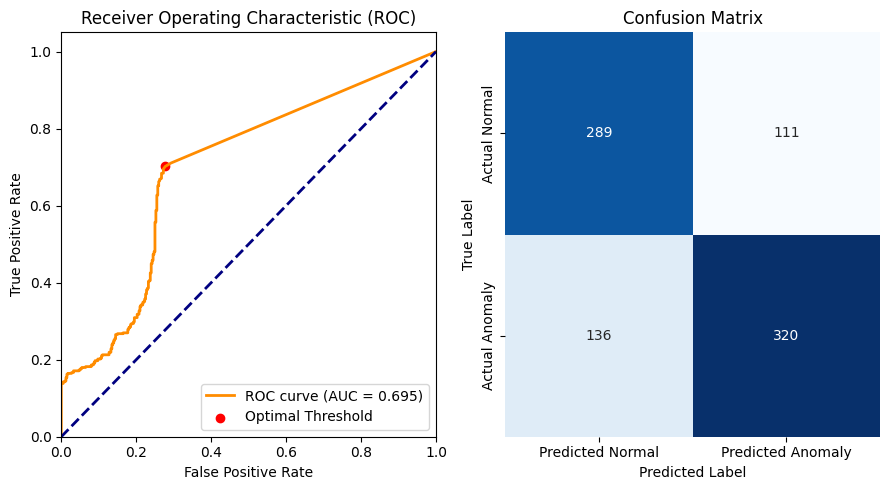

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ==========================================
# 1. FIND THE OPTIMAL THRESHOLD
# ==========================================
# y_true and y_scores are generated from the previous evaluation loop
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Calculate Youden's J statistic to find the optimal threshold
# This maximizes True Positives while minimizing False Positives
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Anomaly Threshold calculated at: {optimal_threshold:.4f}")

# Convert continuous scores to binary predictions using the threshold
y_pred = [1 if score >= optimal_threshold else 0 for score in y_scores]

# ==========================================
# 2. PLOT 1: THE ROC CURVE
# ==========================================

plt.figure(figsize=(9, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# ==========================================
# 3. PLOT 2: CLASSIFICATION REPORT HEATMAP
# ==========================================

# plt.subplot(1, 3, 2)

# # Get the report as a dictionary instead of a string
# report_dict = classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"], output_dict=True)

# # Convert to a Pandas DataFrame and transpose it for the heatmap
# report_df = pd.DataFrame(report_dict).transpose()

# # Drop the 'support' column (which is just the count of items) so the color scale isn't thrown off
# sns.heatmap(report_df.drop(columns=['support']), annot=True, cmap='viridis', vmin=0.0, vmax=1.0, fmt='.3f')
# plt.title('Classification Report Metrics')

# ==========================================
# 4. PLOT 3: CONFUSION MATRIX
# ==========================================

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [29]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70       400
           1       0.74      0.70      0.72       456

    accuracy                           0.71       856
   macro avg       0.71      0.71      0.71       856
weighted avg       0.71      0.71      0.71       856



In [33]:
model.eval()

example_input = torch.randn(1, 1, 160000).to(device)

traced_model = torch.jit.trace(model, example_input)
traced_model.save("sw_wavenet_traced.pt")

In [34]:
torch.save(model.state_dict(), "sw_wavenet.pth")